In [ ]:
import pandas as pd
# Lire le fichier CSV

df = pd.read_csv('../data/retail_sales_dataset.csv')

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [4]:
df.describe()


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [5]:
df.isnull().sum()


Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [6]:
df = df.dropna()


In [21]:
# Calculer le total des ventes (somme de la colonne Total Amount)
total_ventes = df['Total Amount'].sum()
# Afficher le résultat
print(f"Total des ventes : {total_ventes}")
#Total des ventes avec mise en forme
print(f"Total : {total_ventes:,.0f}")
# 2. Total par catégorie
print("\n--- Total par catégorie ---")
print(df.groupby('Product Category')['Total Amount'].sum())
# 3. Total par mois (corrigé)
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
print("\n--- Total par mois ---")
print(df.groupby('Month')['Total Amount'].sum())

Total des ventes : 456000
Total : 456,000

--- Total par catégorie ---
Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

--- Total par mois ---
Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64


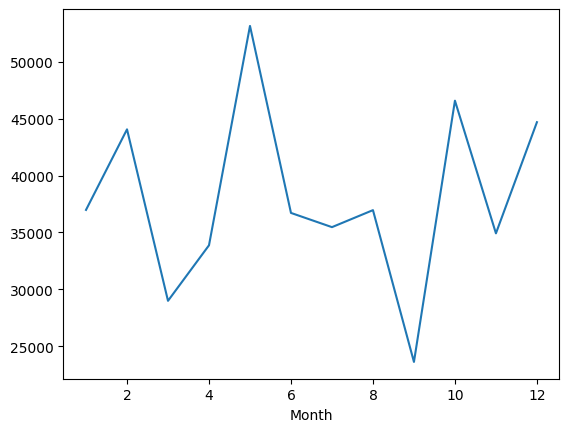

In [23]:
import matplotlib.pyplot as plt

df.groupby('Month')['Total Amount'].sum().plot()
plt.show()

<Axes: xlabel='Product Category'>

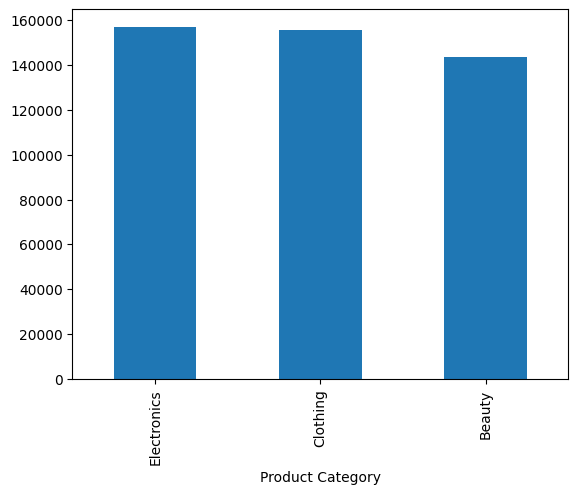

In [25]:
top_products = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar')

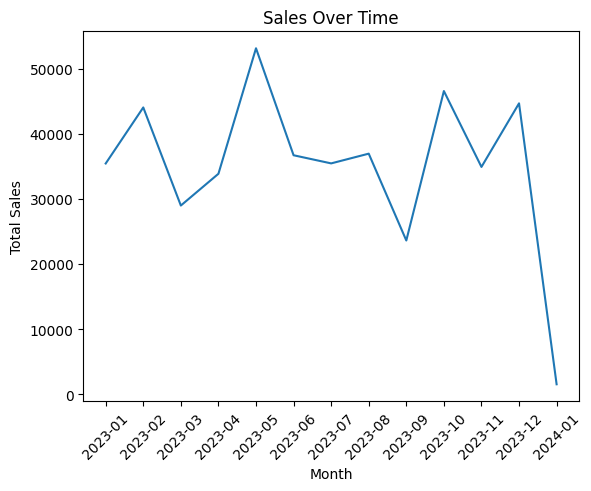

In [ ]:



# Convertir la colonne Date en format datetime
df['Date'] = pd.to_datetime(df['Date'])

# Créer monthly_sales (ventes par mois)
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

# OU si vous préférez avec des mois numériques (1 à 12) :
# df['Month'] = df['Date'].dt.month
# monthly_sales = df.groupby('Month')['Total Amount'].sum()

# Maintenant le graphique fonctionne
sns.lineplot(x=monthly_sales.index.astype(str), y=monthly_sales.values)
plt.title("Sales Over Time")
plt.xticks(rotation=45)  # Pour mieux lire les dates
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

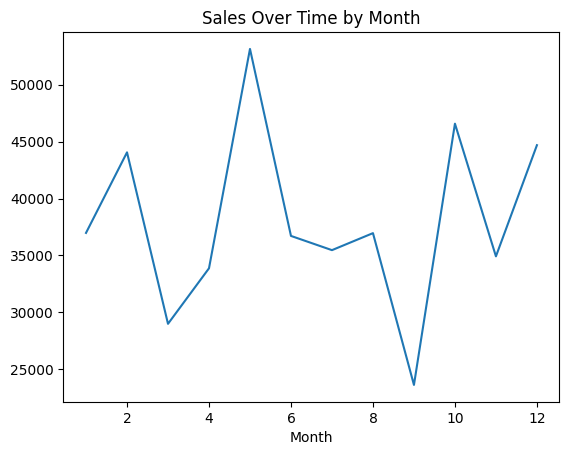

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
df['Month'] = pd.to_datetime(df['Date']).dt.month
monthly_sales = df.groupby('Month')['Total Amount'].sum()

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title("Sales Over Time by Month")
plt.show()

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
Freq: M, Name: Total Amount, dtype: int64


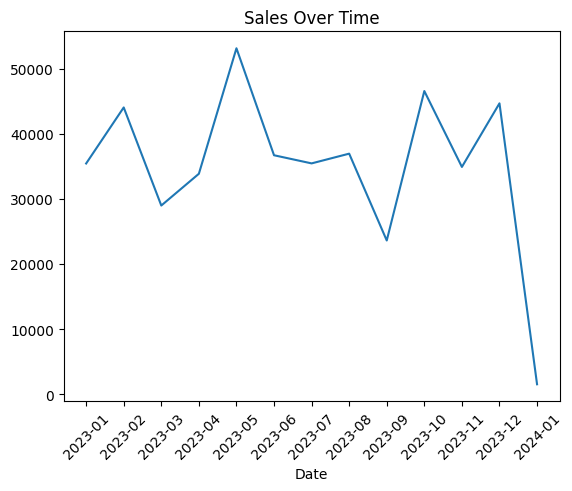

In [30]:
# Avant de tracer, vérifiez
print(monthly_sales.head())  # Pour voir si la variable est définie


monthly_sales = df.groupby(pd.to_datetime(df['Date']).dt.to_period('M'))['Total Amount'].sum()

# Convertir les périodes en string pour l'affichage
sns.lineplot(x=monthly_sales.index.astype(str), y=monthly_sales.values)
plt.title("Sales Over Time")
plt.xticks(rotation=45)
plt.show()